In [1]:
'''!pip install tslearn
!unzip processed_dataset_npz.zip'''

'!pip install tslearn\n!unzip processed_dataset_npz.zip'

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import glob
from tabnanny import verbose
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tslearn.shapelets import LearningShapelets
import math
from sklearn.metrics import accuracy_score, classification_report
from tslearn.svm import TimeSeriesSVC
from torch.utils.data import Dataset, DataLoader,TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tslearn.utils import to_time_series_dataset
from tslearn.preprocessing import TimeSeriesScalerMinMax,TimeSeriesResampler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix
import gc
import warnings
warnings.filterwarnings('ignore')
os.environ["KERAS_BACKEND"] = "torch"


In [4]:
DATASET_DIR = "processed_dataset_npz"
BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_PATH = '/content/drive/MyDrive/MLproje'

# Dataset class for loading and preprocessing human action keypoint data.
class HumanActionDataset(Dataset):
    # Initialize the class instance.
    def __init__(self, root_dir):
        self.data = []
        self.labels = []
        self.file_paths = []

        if not os.path.exists(root_dir):
            raise RuntimeError(f"Folder not found: {root_dir}")

        self.classes = sorted(os.listdir(root_dir))
        self.le = LabelEncoder()
        self.le.fit(self.classes)

        print(f"Classes: {self.classes}")

        for label in self.classes:
            class_path = os.path.join(root_dir, label)
            if not os.path.isdir(class_path): continue

            for npz_file in glob.glob(os.path.join(class_path, "*.npz")):
                try:
                    f = np.load(npz_file, allow_pickle=True)
                    seq = f['normalized_keypoints'].astype(np.float32)

                    if seq.shape[0] > 5:
                        self.data.append(seq)
                        self.labels.append(label)
                        self.file_paths.append(npz_file)
                except Exception as e:
                    print(f"Error ({npz_file}): {e}")

        self.encoded_labels = self.le.transform(self.labels)
        print(f"Total Videos Loaded: {len(self.data)}")

        self.max_seq_len = max([s.shape[0] for s in self.data])
        print(f"Longest video in dataset: {self.max_seq_len} frames. All data will be interpolated to this length.")

    # Return the total number of samples in the dataset.
    def __len__(self):
        return len(self.data)

    # Get a specific sample from the dataset by index.
    def __getitem__(self, idx):
        seq_numpy = self.data[idx]
        label = self.encoded_labels[idx]

        sequence_torch = torch.tensor(seq_numpy, dtype=torch.float32)
        #standartization for better features
        seq_tensor = (sequence_torch - sequence_torch.mean()) / (sequence_torch.std() + 1e-7)

        seq_tensor = seq_tensor.unsqueeze(0)

        seq_tensor = seq_tensor.permute(0, 2, 1)

        seq_resized = F.interpolate(seq_tensor, size=self.max_seq_len, mode='linear', align_corners=False)

        seq_resized = seq_resized.permute(0, 2, 1)

        seq_resized = seq_resized.squeeze(0)

        return seq_resized, torch.tensor(label, dtype=torch.long)

    # Prepare data for scikit-learn models (e.g., SVM).
    def get_sklearn_data(self):
        return self.data, self.encoded_labels

    # Prepare data for hybrid shapelet-based models.
    def get_hybrid_shapelet_data(self, target_len=150):


        repeated_data_list = []

        for seq_numpy in self.data:
            curr_len = seq_numpy.shape[0]

            if curr_len < self.max_seq_len:
                n_repeats = (self.max_seq_len // curr_len) + 1

                seq_repeated = np.tile(seq_numpy, (n_repeats, 1))

                seq_final = seq_repeated[:self.max_seq_len, :]
            else:
                seq_final = seq_numpy[:self.max_seq_len, :]

            repeated_data_list.append(seq_final)


        formatted_dataset = to_time_series_dataset(repeated_data_list)

        print(f"Data {self.max_seq_len} from size {target_len} to size is being resampled...")
        resampler = TimeSeriesResampler(sz=target_len)
        X_resampled = resampler.fit_transform(formatted_dataset)

        print("Applying MinMax Normalization...")
        scaler = TimeSeriesScalerMinMax(value_range=(0., 1.))
        X_scaled = scaler.fit_transform(X_resampled)

        print(f"Process Complete. Output Shape: {X_scaled.shape}")

        return X_scaled, self.encoded_labels

full_dataset = HumanActionDataset(DATASET_DIR)

indices = np.arange(len(full_dataset))
train_idx, test_idx = train_test_split(indices, test_size=0.15, random_state=42, stratify=full_dataset.encoded_labels)
train_idx , val_idx = train_test_split(train_idx,test_size=0.15, random_state=42, stratify=full_dataset.encoded_labels[train_idx])

train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
validation_dataset = torch.utils.data.Subset(full_dataset,val_idx)
test_dataset = torch.utils.data.Subset(full_dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Classes: ['boxing', 'handclapping', 'handwaving', 'jogging', 'running', 'walking']
Total Videos Loaded: 599
Longest video in dataset: 1492 frames. All data will be interpolated to this length.


In [5]:


# Custom LSTM cell implementation with optional peephole connections and normalization.
class CustomLSTMCell(nn.Module):
    # Initialize the class instance.
    def __init__(self, input_size, hidden_size):
        super(CustomLSTMCell, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size

        stdv = 1.0 / math.sqrt(hidden_size)

        self.W_i = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.U_i = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.b_i = nn.Parameter(torch.Tensor(hidden_size))

        self.W_f = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.U_f = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.b_f = nn.Parameter(torch.Tensor(hidden_size))

        self.W_c = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.U_c = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.b_c = nn.Parameter(torch.Tensor(hidden_size))

        self.W_o = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.U_o = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.b_o = nn.Parameter(torch.Tensor(hidden_size))

        self.P_i = nn.Parameter(torch.Tensor(hidden_size))
        self.P_f = nn.Parameter(torch.Tensor(hidden_size))
        self.P_o = nn.Parameter(torch.Tensor(hidden_size))

        self.init_weights(stdv)

        self.ln_i = nn.LayerNorm(hidden_size)
        self.ln_f = nn.LayerNorm(hidden_size)
        self.ln_c = nn.LayerNorm(hidden_size)
        self.ln_o = nn.LayerNorm(hidden_size)

        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()

    # Initialize weights for the layer/model.
    def init_weights(self, stdv):
        for p in self.parameters():
            p.data.uniform_(-stdv, stdv)
        with torch.no_grad():
            self.b_f.data.fill_(1.0)

    # Forward pass of the neural network module.
    def forward(self, x, states):
        h_prev, c_prev = states

        i_linear = torch.mm(x, self.W_i) + torch.mm(h_prev, self.U_i) + self.b_i
        f_linear = torch.mm(x, self.W_f) + torch.mm(h_prev, self.U_f) + self.b_f
        c_linear = torch.mm(x, self.W_c) + torch.mm(h_prev, self.U_c) + self.b_c
        o_linear = torch.mm(x, self.W_o) + torch.mm(h_prev, self.U_o) + self.b_o

        i_linear += self.P_i * c_prev
        f_linear += self.P_f * c_prev

        i_t = self.sigmoid(self.ln_i(i_linear))
        f_t = self.sigmoid(self.ln_f(f_linear))
        g_t = self.tanh(self.ln_c(c_linear))

        c_next = (f_t * c_prev) + (i_t * g_t)

        o_linear += self.P_o * c_next

        o_t = self.sigmoid(self.ln_o(o_linear))

        h_next = o_t * self.tanh(c_next)

        return h_next, c_next



# Stacked LSTM model implementation for sequence processing.
class CustomStackedLSTM(nn.Module):
    # Initialize the class instance.
    def __init__(self, input_size, hidden_size, num_layers=1, dropout=0.1):
        super(CustomStackedLSTM, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout_rate = dropout

        self.layers = nn.ModuleList()

        for i in range(num_layers):
            layer_input_dim = input_size if i == 0 else hidden_size

            cell = CustomLSTMCell(layer_input_dim, hidden_size)
            self.layers.append(cell)

        self.dropout = nn.Dropout(dropout)

    # Forward pass of the neural network module.
    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        current_layer_input = x

        for layer_idx, cell in enumerate(self.layers):

            h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
            c_t = torch.zeros(batch_size, self.hidden_size).to(x.device)

            layer_outputs = []

            for t in range(seq_len):
                inp = current_layer_input[:, t, :]

                h_t, c_t = cell(inp, (h_t, c_t))

                layer_outputs.append(h_t)

            current_layer_input = torch.stack(layer_outputs, dim=1)

            if layer_idx < self.num_layers - 1:
                current_layer_input = self.dropout(current_layer_input)

        last_time_step_output = current_layer_input[:, -1, :]

        return last_time_step_output

# Classifier model combining an LSTM encoder and a linear output head.
class CustomLSTMClassifier(nn.Module):
    # Initialize the class instance.
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes):
        super(CustomLSTMClassifier, self).__init__()

        self.lstm = CustomStackedLSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=0.2
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    # Forward pass of the neural network module.
    def forward(self, x):
        features = self.lstm(x)
        logits = self.classifier(features)

        return logits

In [6]:



# Custom linear layer implementation with integrated batch normalization.
class CustomLinear(nn.Module):
    # Initialize the class instance.
    def __init__(self, in_features, out_features):
        super(CustomLinear, self).__init__()

        self.in_features = in_features
        self.out_features = out_features

        stdv = 1.0 / math.sqrt(out_features)
        self.weights = nn.Parameter(torch.Tensor(in_features, out_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))

        self.bn = nn.BatchNorm1d(out_features)

        self.init_weights(stdv)

    # Initialize weights for the layer/model.
    def init_weights(self, stdv):
        for p in self.parameters():
            p.data.uniform_(-stdv, stdv)
        with torch.no_grad():
            self.bias.data.fill_(0.0)

    # Forward pass of the neural network module.
    def forward(self, x):
        x = torch.mm(x, self.weights) + self.bias

        x = self.bn(x)
        return x

# Multi-Layer Perceptron (MLP) for classification tasks.
class MLPClassifier(nn.Module):
    # Initialize the class instance.
    def __init__(self, input_dim, hidden_sizes, num_classes, dropout_rate=0.2):
        super(MLPClassifier, self).__init__()

        self.model = nn.Sequential()

        current_dim = input_dim

        for i, h_dim in enumerate(hidden_sizes):
            layer_name = f"fc{i+1}"
            act_name = f"relu{i+1}"
            dropout_name = f"dropout{i+1}"
            self.model.add_module(layer_name, CustomLinear(current_dim, h_dim))

            self.model.add_module(act_name, nn.ReLU())

            self.model.add_module(dropout_name, nn.Dropout(p=dropout_rate))

            current_dim = h_dim

        self.model.add_module("fc_out", CustomLinear(current_dim, num_classes))

    # Forward pass of the neural network module.
    def forward(self, x):
        return self.model(x)


# Hybrid model using time-series shapelets for feature extraction followed by an MLP.
class ShapeletsMLP(nn.Module):
    # Initialize the class instance.
    def __init__(self,device, n_shapelets_per_size, hidden_sizes_mlp, num_classes, dropout_rate=0.2, max_iter=50):
        super(ShapeletsMLP, self).__init__()

        self.device=device

        self.shapelet_model = LearningShapelets(
            n_shapelets_per_size=n_shapelets_per_size,
            optimizer="adam",
            batch_size=16,
            max_iter=max_iter,
            verbose=0,
            scale=True
            )

        self.total_shapelets = sum(n_shapelets_per_size.values())

        self.classifier = MLPClassifier(
            input_dim=self.total_shapelets,
            hidden_sizes=hidden_sizes_mlp,
            num_classes=num_classes,
            dropout_rate=dropout_rate
        )

        self.shapelets_fitted = False

    # Learn shapelet features from the input training data.
    def fit_shapelets_representation(self, X_train, y_train):
        print("Shapelet training (Feature Extraction) ")
        self.shapelet_model.fit(X_train, y_train)
        self.shapelets_fitted = True

        for param in self.shapelet_model.model_.parameters():
            param.requires_grad = False
        print("Shapelets freezzed.")

    def forward(self, x):
        """
        x: Torch Tensor (Batch, Time, Channels)
        """
        if not self.shapelets_fitted:
            raise RuntimeError("Before fit_shapelets_representation() !")

        with torch.no_grad():
            features = self.shapelet_model.transform(x.detach().cpu().numpy())

        features_tensor = torch.tensor(features, dtype=torch.float32).to(x.device)
        return self.classifier(features_tensor)

In [7]:
# Custom 1D Convolution layer using matrix operations.
class CustomConv1d(nn.Module):
    # Initialize the class instance.
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super(CustomConv1d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        self.weight = nn.Parameter(torch.Tensor(out_channels, in_channels * kernel_size))
        self.bias = nn.Parameter(torch.Tensor(out_channels))

        self.bn = nn.BatchNorm1d(out_channels)
        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)

    # Forward pass of the neural network module.
    def forward(self, x):
        batch_size, _, l_in = x.shape

        l_out = ((l_in + 2 * self.padding - self.kernel_size) // self.stride) + 1

        x_4d = x.unsqueeze(2)
        x_unf = F.unfold(x_4d,
                         kernel_size=(1, self.kernel_size),
                         stride=(1, self.stride),
                         padding=(0, self.padding))

        out_unf = torch.matmul(x_unf.transpose(1, 2), self.weight.t())
        out_unf = out_unf.transpose(1, 2)

        out = F.fold(out_unf,
                     output_size=(1, l_out),
                     kernel_size=(1, 1))

        out = out.squeeze(2) + self.bias.view(1, -1, 1)
        return self.bn(out)


# Classifier model using 1D convolutional layers for feature extraction.
class CNNClassifier(nn.Module):
    # Initialize the class instance.
    def __init__(self, in_channels, hidden_channels, kernel_size, num_classes, dropout_rate=0.1):
        super(CNNClassifier, self).__init__()
        self.model = nn.Sequential()

        current_channels = in_channels

        for i, h_channels in enumerate(hidden_channels):
            conv_name = f"conv{i + 1}"
            relu_name = f"relu{i + 1}"
            pool_name = f"pool{i + 1}"
            dropout_name = f"dropout{i + 1}"
            self.model.add_module(conv_name,
                                  CustomConv1d(current_channels, h_channels, kernel_size, padding=kernel_size // 2))

            self.model.add_module(relu_name, nn.ReLU())

            self.model.add_module(pool_name, nn.MaxPool1d(kernel_size=2))

            self.model.add_module(dropout_name, nn.Dropout(p=dropout_rate))

            current_channels = h_channels

        self.model.add_module("global_pool", nn.AdaptiveAvgPool1d(1))
        self.model.add_module("flatten", nn.Flatten())

        self.model.add_module("fc_out", nn.Linear(current_channels, num_classes))

    # Forward pass of the neural network module.
    def forward(self, x):
        return self.model(x.transpose(1, 2))

In [8]:
# SVM classifier specifically designed for time series using the Global Alignment Kernel (GAK).
class CustomGAKSVM:
    # Initialize the class instance.
    def __init__(self, gamma='auto', C=1.0, n_jobs=-1, verbose=0):
        self.model = TimeSeriesSVC(
            kernel="gak",
            gamma=gamma,
            C=C,
            n_jobs=n_jobs,
            verbose=verbose
        )
        self.gamma = gamma
        self.C = C

    # Train the model on the provided dataset.
    def fit(self, X_train, y_train):
        X_formatted = to_time_series_dataset(X_train)
        print(f"SVM Training (Gamma={self.gamma}, C={self.C})...")
        self.model.fit(X_formatted, y_train)
        print("Training Complete.")

    # Perform inference on test data.
    def predict(self, X_test):
        X_formatted = to_time_series_dataset(X_test)
        return self.model.predict(X_formatted)

    # Calculate accuracy and other metrics on a test set.
    def evaluate(self, X_test, y_test):
        preds = self.predict(X_test)
        acc = accuracy_score(y_test, preds)
        return acc, preds

In [9]:
# Utility function to train and evaluate a PyTorch model.
def train_evaluate_pytorch(model, name, train_loader=train_loader, val_loader=validation_loader, epochs=20, lr=1e-3, weight_decay=1e-4, save_dir="models_checkpoint"):
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.01)
    criterion = nn.CrossEntropyLoss()
    save_path = os.path.join(save_dir, f"{name}_best.pth")
    best_val_loss = float('inf')
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        model.eval()
        total_val_loss = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                total_val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = accuracy_score(all_labels, all_preds) * 100

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        print(f"Epoch {epoch+1}/{epochs} | LR: {current_lr:.6f} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: %{val_acc:.2f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)

    model.load_state_dict(torch.load(save_path))

    return best_val_loss

In [10]:
def test_evaluate_pytorch(model, test_loader=test_loader, class_names=None):
    model.eval()
    model = model.to(DEVICE)
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4,output_dict=True)
    return acc, all_preds,all_labels,report

In [11]:
FINAL_RESULTS = {}

# Function to visualize the confusion matrix using matplotlib and seaborn.
def plot_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('GT')
    plt.xlabel('PREDICT')
    plt.show()

def plot_ablation_results(results_list, param_name, model_name):
    df = pd.DataFrame(results_list)
    plt.figure(figsize=(8, 4))
    sns.barplot(data=df, x=param_name, y='Accuracy', palette='viridis')
    plt.title(f'{model_name}: {param_name} affect')
    plt.ylim(0, 1.0)
    plt.ylabel("Accuracy")
    plt.show()

def show_report(report):
    df = pd.DataFrame(report).transpose()
    return df.style.background_gradient(cmap='viridis', subset=['precision', 'recall', 'f1-score']).format("{:.2f}")

**TEST : GRID SEARCH**


LSTM ABLATION STUDY STARTING...

 Trying: {'hidden_dim': 96, 'num_layers': 1}
Epoch 1/30 | LR: 0.010000 | Train Loss: 1.5161 | Val Loss: 1.1278 | Val Acc: %42.86
Epoch 2/30 | LR: 0.009973 | Train Loss: 1.0330 | Val Loss: 0.9610 | Val Acc: %46.75
Epoch 3/30 | LR: 0.009892 | Train Loss: 0.9184 | Val Loss: 1.0167 | Val Acc: %55.84
Epoch 4/30 | LR: 0.009758 | Train Loss: 0.8804 | Val Loss: 0.9491 | Val Acc: %50.65
Epoch 5/30 | LR: 0.009572 | Train Loss: 0.8302 | Val Loss: 0.9028 | Val Acc: %63.64
Epoch 6/30 | LR: 0.009337 | Train Loss: 0.8262 | Val Loss: 0.9595 | Val Acc: %59.74
Epoch 7/30 | LR: 0.009055 | Train Loss: 0.7896 | Val Loss: 0.8582 | Val Acc: %57.14
Epoch 8/30 | LR: 0.008729 | Train Loss: 0.7347 | Val Loss: 0.8685 | Val Acc: %58.44
Epoch 9/30 | LR: 0.008362 | Train Loss: 0.7057 | Val Loss: 0.8994 | Val Acc: %59.74
Epoch 10/30 | LR: 0.007960 | Train Loss: 0.7246 | Val Loss: 0.9317 | Val Acc: %57.14
Epoch 11/30 | LR: 0.007525 | Train Loss: 0.6849 | Val Loss: 0.8638 | Val Acc: %6

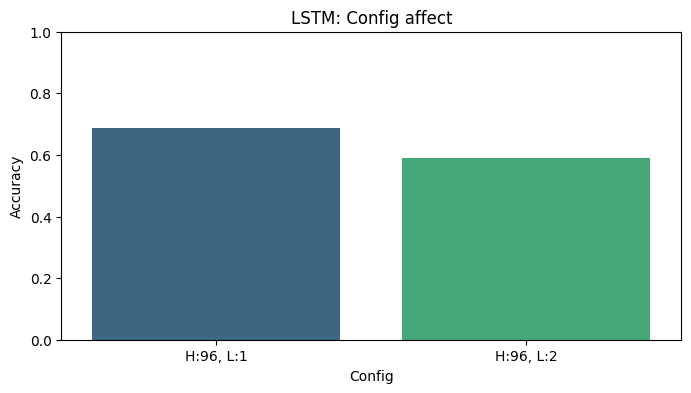

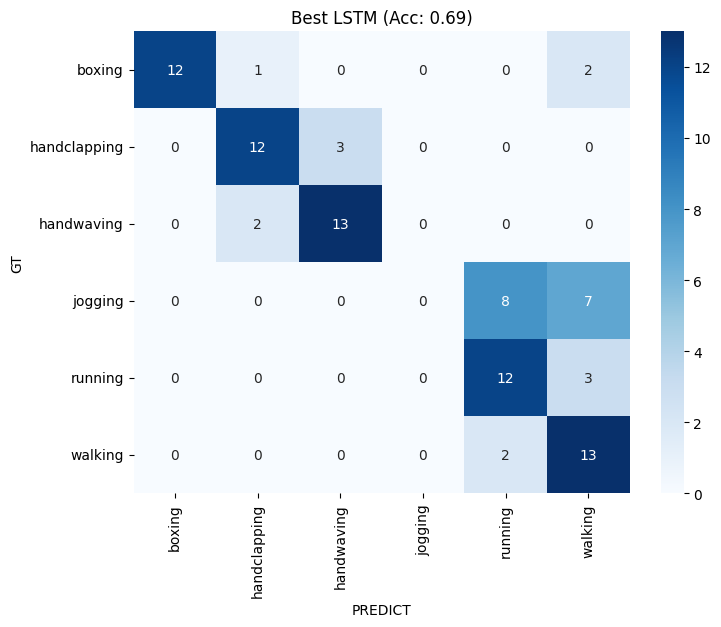

In [12]:
print("\nLSTM ABLATION STUDY STARTING...")

lstm_configs = [
    {'hidden_dim': 96, 'num_layers': 1},
    {'hidden_dim': 96, 'num_layers': 2},
]

lstm_results = []
best_lstm_acc = 0
best_lstm_preds = []
best_lstm_labels = []
best_lstm_result = []

for cfg in lstm_configs:
    print(f"\n Trying: {cfg}")

    model = CustomLSTMClassifier(
        input_dim=75,
        hidden_dim=cfg['hidden_dim'],
        num_layers=cfg['num_layers'],
        num_classes=6
    )

    val_loss = train_evaluate_pytorch(model=model,name = "LSTM" + str(cfg['num_layers']), epochs=30, lr=1e-2 ,weight_decay=1e-3,save_dir = SAVE_PATH)
    acc ,preds,labels, result = test_evaluate_pytorch(model,class_names=full_dataset.classes)

    lstm_results.append({
        'Config': f"H:{cfg['hidden_dim']}, L:{cfg['num_layers']}",
        'Accuracy': acc
    })

    if acc > best_lstm_acc:
        best_lstm_acc = acc
        best_lstm_preds = preds
        best_lstm_labels = labels
        best_lstm_result = result
        torch.save(model.state_dict(), os.path.join(SAVE_PATH, "LSTM_best.pth"))

FINAL_RESULTS['LSTM'] = best_lstm_acc
show_report(best_lstm_result)
plot_ablation_results(lstm_results, 'Config', 'LSTM')
plot_confusion_matrix(best_lstm_labels, best_lstm_preds, full_dataset.classes, f"Best LSTM (Acc: {best_lstm_acc:.2f})")


 CNN ABLATION STUDY STARTING...

 Trying: {'hidden': [64, 128], 'kernel': 3}
Epoch 1/300 | LR: 0.001000 | Train Loss: 1.6170 | Val Loss: 1.4968 | Val Acc: %53.25
Epoch 2/300 | LR: 0.001000 | Train Loss: 1.2189 | Val Loss: 1.2115 | Val Acc: %53.25
Epoch 3/300 | LR: 0.001000 | Train Loss: 1.0327 | Val Loss: 1.0382 | Val Acc: %55.84
Epoch 4/300 | LR: 0.001000 | Train Loss: 0.9171 | Val Loss: 0.9377 | Val Acc: %68.83
Epoch 5/300 | LR: 0.001000 | Train Loss: 0.8391 | Val Loss: 0.8733 | Val Acc: %63.64
Epoch 6/300 | LR: 0.000999 | Train Loss: 0.8085 | Val Loss: 0.8338 | Val Acc: %70.13
Epoch 7/300 | LR: 0.000999 | Train Loss: 0.7327 | Val Loss: 0.8018 | Val Acc: %67.53
Epoch 8/300 | LR: 0.000999 | Train Loss: 0.7050 | Val Loss: 0.7760 | Val Acc: %66.23
Epoch 9/300 | LR: 0.000998 | Train Loss: 0.6737 | Val Loss: 0.7569 | Val Acc: %64.94
Epoch 10/300 | LR: 0.000998 | Train Loss: 0.6276 | Val Loss: 0.7164 | Val Acc: %66.23
Epoch 11/300 | LR: 0.000997 | Train Loss: 0.6123 | Val Loss: 0.6900 | V

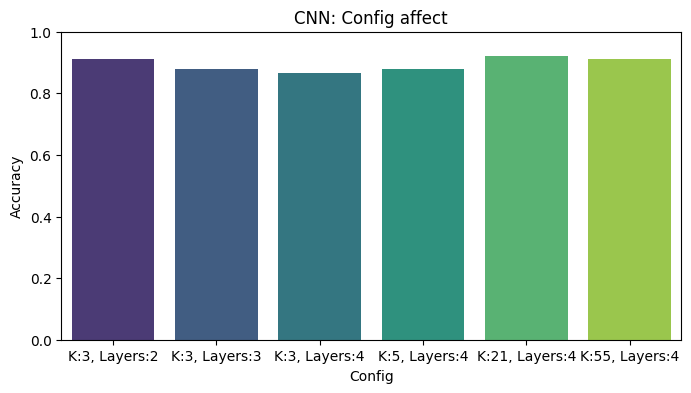

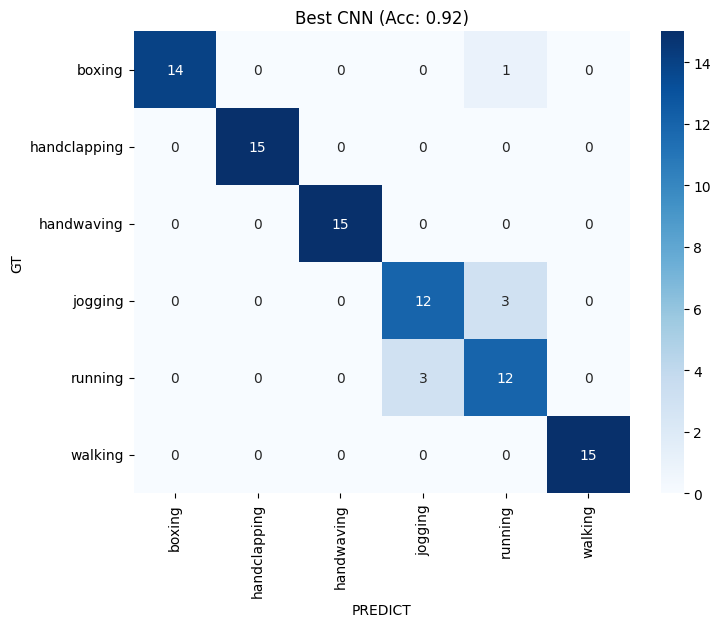

In [15]:
print("\n CNN ABLATION STUDY STARTING...")

cnn_configs = [
    {'hidden': [64, 128], 'kernel': 3},
    {'hidden': [64, 128, 256], 'kernel': 3},
    {'hidden': [64, 128, 256, 512], 'kernel': 3},
    {'hidden': [64, 128, 256, 512], 'kernel': 5},
    {'hidden': [64, 128, 256, 512], 'kernel': 21},
    {'hidden': [64, 128, 256, 512], 'kernel': 55}
]

cnn_results = []
best_cnn_acc = 0
best_cnn_preds = []
best_cnn_labels = []

for cfg in cnn_configs:
    print(f"\n Trying: {cfg}")

    model = CNNClassifier(
        in_channels=75,
        hidden_channels=cfg['hidden'],
        kernel_size=cfg['kernel'],
        num_classes=6,
        dropout_rate=0.2
    )

    val_loss = train_evaluate_pytorch(model=model,name = "CNN" + str(cfg['hidden'][-1])+str(cfg['kernel']), epochs=300, lr=1e-3,weight_decay=1e-4,save_dir = SAVE_PATH)
    acc ,preds,labels, result = test_evaluate_pytorch(model,class_names=full_dataset.le.classes_)

    cnn_results.append({
        'Config': f"K:{cfg['kernel']}, Layers:{len(cfg['hidden'])}",
        'Accuracy': acc
    })

    if acc > best_cnn_acc:
        best_cnn_acc = acc
        best_cnn_preds = preds
        best_cnn_labels = labels
        best_cnn_result = result
        torch.save(model.state_dict(), os.path.join(SAVE_PATH, "CNN_best.pth"))


FINAL_RESULTS['CNN'] = best_cnn_acc
show_report(best_cnn_result)
plot_ablation_results(cnn_results, 'Config', 'CNN')
plot_confusion_matrix(best_cnn_labels, best_cnn_preds, full_dataset.classes, f"Best CNN (Acc: {best_cnn_acc:.2f})")


 SHAPELET + MLP ABLATION STUDY STARTING...
Data 1492 from size 150 to size is being resampled...
Applying MinMax Normalization...
Process Complete. Output Shape: (599, 150, 75)

 Trying: Shapelets={50: 8}, Hidden=[256, 512, 512, 256]
Shapelet training (Feature Extraction) 
Shapelets freezzed.
Epoch 1/100 | LR: 0.010000 | Train Loss: 1.7399 | Val Loss: 1.8200 | Val Acc: %16.88
Epoch 2/100 | LR: 0.009998 | Train Loss: 1.6468 | Val Loss: 1.8138 | Val Acc: %16.88
Epoch 3/100 | LR: 0.009990 | Train Loss: 1.5838 | Val Loss: 1.8021 | Val Acc: %16.88
Epoch 4/100 | LR: 0.009978 | Train Loss: 1.5510 | Val Loss: 1.7824 | Val Acc: %16.88
Epoch 5/100 | LR: 0.009961 | Train Loss: 1.4948 | Val Loss: 1.7416 | Val Acc: %22.08
Epoch 6/100 | LR: 0.009939 | Train Loss: 1.4412 | Val Loss: 1.6504 | Val Acc: %31.17
Epoch 7/100 | LR: 0.009912 | Train Loss: 1.4018 | Val Loss: 1.5922 | Val Acc: %24.68
Epoch 8/100 | LR: 0.009881 | Train Loss: 1.3841 | Val Loss: 1.4131 | Val Acc: %54.55
Epoch 9/100 | LR: 0.00984

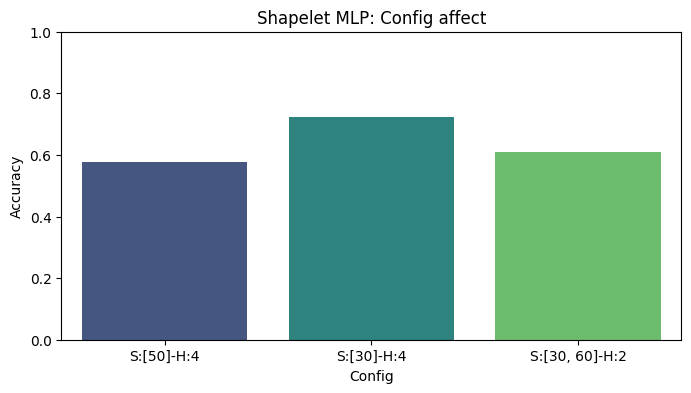

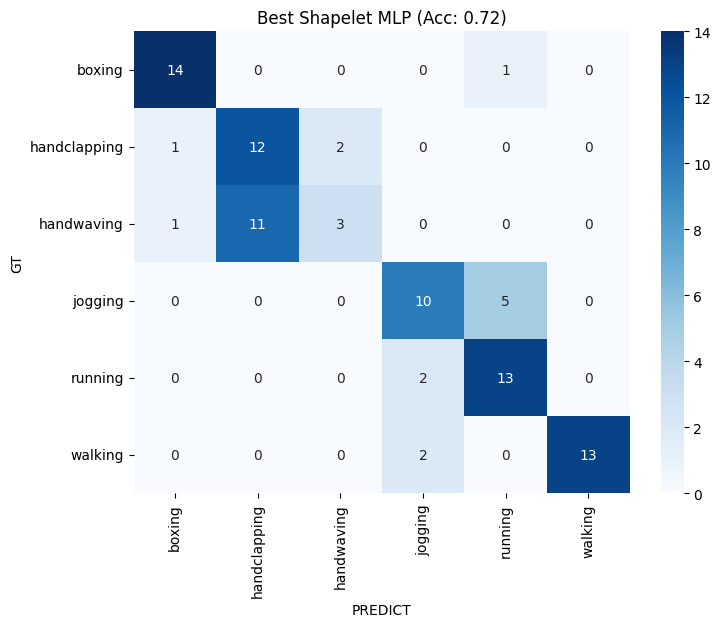

In [18]:

print("\n SHAPELET + MLP ABLATION STUDY STARTING...")

x_all, y_all = full_dataset.get_hybrid_shapelet_data()
x_all = np.asarray(x_all)
y_all = np.asarray(y_all)

X_train_np = x_all[train_idx]
y_train_np = y_all[train_idx]
X_val_np = x_all[val_idx]
y_val_np = y_all[val_idx]
X_test_np = x_all[test_idx]
y_test_np = y_all[test_idx]

X_train_shapelet, _, y_train_shapelet, _ = train_test_split(
    X_train_np, y_train_np, test_size=0.85, stratify=y_train_np, random_state=42
)

X_train_torch = torch.tensor(X_train_np, dtype=torch.float32).to(DEVICE)
y_train_torch = torch.tensor(y_train_np, dtype=torch.long).to(DEVICE)
X_val_torch = torch.tensor(X_val_np, dtype=torch.float32).to(DEVICE)
y_val_torch = torch.tensor(y_val_np, dtype=torch.long).to(DEVICE)
X_test_torch = torch.tensor(X_test_np, dtype=torch.float32).to(DEVICE)
y_test_torch = torch.tensor(y_test_np, dtype=torch.long).to(DEVICE)

train_ds = TensorDataset(X_train_torch, y_train_torch)
mlp_train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

val_ds = TensorDataset(X_val_torch, y_val_torch)
mlp_val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=True)


test_ds = TensorDataset(X_test_torch, y_test_torch)
mlp_test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=True)


mlp_configs = [
    {'shapelets': {50: 8}, 'hidden': [256, 512, 512, 256]},

    {'shapelets': {30: 8}, 'hidden': [256, 512, 512, 256]},

    {'shapelets': {30: 4, 60: 4}, 'hidden': [256, 128]},
]

mlp_results = []
best_mlp_acc = 0
best_mlp_preds = []
best_mlp_labels = []
best_mlp_result = []

for cfg in mlp_configs:

    print(f"\n Trying: Shapelets={cfg['shapelets']}, Hidden={cfg['hidden']}")

    shp_parts = [f"S{k}x{v}" for k, v in sorted(cfg['shapelets'].items())]
    shp_name = "_".join(shp_parts)
    hidden_name = "MLP" + "_".join(map(str, cfg['hidden']))
    unique_name = f"{shp_name}_{hidden_name}"

    mlpmodel = ShapeletsMLP(
        n_shapelets_per_size=cfg['shapelets'],
        device=DEVICE,
        hidden_sizes_mlp=cfg['hidden'],
        num_classes=6,
        dropout_rate=0.4,
        max_iter=500,
    ).to(DEVICE)

    mlpmodel.fit_shapelets_representation(
        torch.tensor(X_train_shapelet),
        torch.tensor(y_train_shapelet)
    )

    val_loss = train_evaluate_pytorch(model=mlpmodel, name=unique_name,train_loader= mlp_train_loader,val_loader=mlp_val_loader,epochs=100,lr=1e-2,weight_decay=6e-3,save_dir = SAVE_PATH)
    acc ,preds,labels, result = test_evaluate_pytorch(model=mlpmodel,test_loader=mlp_test_loader,class_names=full_dataset.le.classes_)

    config_name = f"S:{list(cfg['shapelets'].keys())}-H:{len(cfg['hidden'])}"
    mlp_results.append({
        'Config': config_name,
        'Accuracy': acc
    })

    if acc > best_mlp_acc:
        best_mlp_acc = acc
        best_mlp_preds = preds
        best_mlp_labels = labels
        best_mlp_result = result
        torch.save(model.state_dict(), os.path.join(SAVE_PATH, "MLP_best.pth"))

FINAL_RESULTS['ShapeletMLP'] = best_mlp_acc
show_report(best_mlp_result)
plot_ablation_results(mlp_results, 'Config', 'Shapelet MLP')
plot_confusion_matrix(best_mlp_labels, best_mlp_preds, full_dataset.classes, f"Best Shapelet MLP (Acc: {best_mlp_acc:.2f})")

In [ ]:


print("\n GAK + SVM ABLATION STUDY STARTING...")
gc.collect()

X_raw_list, y_raw = full_dataset.get_sklearn_data()
X_train_svm = [X_raw_list[i][::4] for i in train_idx]
y_train_svm = y_raw[train_idx]
X_test_svm = [X_raw_list[i][::4] for i in test_idx]
y_test_svm = y_raw[test_idx]

X_train_svm = to_time_series_dataset(X_train_svm)
X_test_svm = to_time_series_dataset(X_test_svm)

svm_configs = [
    {'C': 1.0, 'gamma': 'auto'},
    {'C': 10.0, 'gamma': 'auto'},
    {'C': 100.0, 'gamma': 'auto'}
]

svm_results = []
best_svm_acc = 0
best_svm_preds = []
best_svm_result = []

for cfg in svm_configs:
    print(f"\n Trying: {cfg}")

    clf = CustomGAKSVM(gamma=cfg['gamma'], C=cfg['C'], n_jobs=-1, verbose=0)

    try:
        clf.fit(X_train_svm, y_train_svm)
        preds = clf.predict(X_test_svm)
        acc = accuracy_score(y_test_svm, preds)
        result = classification_report(y_test_svm,preds,target_names=full_dataset.classes,output_dict=True)
        print(f"   Accuracy: {acc:.2f}")

        svm_results.append({
            'Config': f"C:{cfg['C']}",
            'Accuracy': acc
        })

        if acc > best_svm_acc:
            best_svm_acc = acc
            best_svm_preds = preds
            best_svm_result = result


    except Exception as e:
        print(f"   Hata: {e}")

FINAL_RESULTS['SVM'] = best_svm_acc
show_report(best_svm_result)
plot_ablation_results(svm_results, 'Config', 'SVM')
plot_confusion_matrix(y_test_svm, best_svm_preds, full_dataset.classes, f"Best SVM (Acc: {best_svm_acc:.2f})")


 GAK + SVM ABLATION STUDY STARTING...

 Trying: {'C': 1.0, 'gamma': 'auto'}
SVM Training (Gamma=auto, C=1.0)...


In [ ]:
print("\n FINAL PROJECT RESULTS ")
print("-" * 30)

results_df = pd.DataFrame(list(FINAL_RESULTS.items()), columns=['Model', 'Best Accuracy'])
print(results_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Best Accuracy', data=results_df, palette='magma')
plt.title("Comparison of All Models (Human Action Recognition)")
plt.ylim(0, 1.05)
plt.ylabel("Test Accuracy")

for index, row in results_df.iterrows():
    # İngilizcede % işareti sona gelir (Örn: 95.5%)
    plt.text(index, row['Best Accuracy'] + 0.02,
             f"{row['Best Accuracy']*100:.1f}%",
             color='black', ha="center", fontweight='bold')

plt.show()